In [ ]:
from google import colab
colab.drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
 import kagglehub

# Download latest version
path = kagglehub.dataset_download("emmarex/plantdisease")

 print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plantdisease' dataset.
Path to dataset files: /kaggle/input/plantdisease


In [ ]:
import shutil

shutil.make_archive("/content/plantdisease", "zip", path)


'/content/plantdisease.zip'

In [ ]:
 shutil.move("/content/plantdisease.zip",
            "/content/drive/MyDrive/plantdisease.zip")


'/content/drive/MyDrive/plantdisease.zip'

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/plantdisease.zip"
extract_path = "/content/plantdisease"   # folder where to extract

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)


Dataset extracted to: /content/plantdisease


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Paths
dataset_path = "/content/plantdisease/PlantVillage"
train_path = "/content/plantdisease/train"
test_path = "/content/plantdisease/test"

# Create train and test directories if they don't exist
os.makedirs(train_path, exist_ok=True)
os.makedirs(test_path, exist_ok=True)

# Get all class folders (each folder in PlantVillage represents a disease class)
class_folders = [f for f in os.listdir(dataset_path)
                if os.path.isdir(os.path.join(dataset_path, f))]

##############################################################
class_folders = sorted(class_folders)[:5]
#############################################################
print("Found classes:", class_folders)
print("Total classes:", len(class_folders))

# Split ratio (adjust as needed)
test_size = 0.2  # 20% for testing, 80% for training
random_state = 42  # for reproducible splits

# Statistics
total_train = 0
total_test = 0

for class_folder in class_folders:
    class_path = os.path.join(dataset_path, class_folder)

    # Get all images in the class folder
    images = [f for f in os.listdir(class_path)
             if os.path.isfile(os.path.join(class_path, f))]

    if len(images) == 0:
        print(f"No images found in {class_folder}, skipping...")
        continue

    # Split images into train and test
    train_imgs, test_imgs = train_test_split(
        images, test_size=test_size, random_state=random_state, shuffle=True
    )

    # Create class directories in train and test folders
    train_class_path = os.path.join(train_path, class_folder)
    test_class_path = os.path.join(test_path, class_folder)
    os.makedirs(train_class_path, exist_ok=True)
    os.makedirs(test_class_path, exist_ok=True)

    # Copy train images
    for img in train_imgs:
        src = os.path.join(class_path, img)
        dst = os.path.join(train_class_path, img)
        shutil.copy2(src, dst)

    # Copy test images
    for img in test_imgs:
        src = os.path.join(class_path, img)
        dst = os.path.join(test_class_path, img)
        shutil.copy2(src, dst)

    print(f"Class {class_folder}: {len(train_imgs)} train, {len(test_imgs)} test images")
    total_train += len(train_imgs)
    total_test += len(test_imgs)

print(f"\nDataset split completed!")
print(f"Total train images: {total_train}")
print(f"Total test images: {total_test}")
print(f"Train data: {train_path}")
print(f"Test data: {test_path}")

print("\nClass distribution:")
for class_folder in class_folders:
    train_class_path = os.path.join(train_path, class_folder)
    test_class_path = os.path.join(test_path, class_folder)

    if os.path.exists(train_class_path):
        train_count = len(os.listdir(train_class_path))
        test_count = len(os.listdir(test_class_path)) if os.path.exists(test_class_path) else 0
        print(f"{class_folder}: {train_count} train, {test_count} test")

Found classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Total classes: 5
Class Pepper__bell___Bacterial_spot: 797 train, 200 test images
Class Pepper__bell___healthy: 1182 train, 296 test images
Class Potato___Early_blight: 800 train, 200 test images
Class Potato___Late_blight: 800 train, 200 test images
Class Potato___healthy: 121 train, 31 test images

Dataset split completed!
Total train images: 3700
Total test images: 927
Train data: /content/plantdisease/train
Test data: /content/plantdisease/test

Class distribution:
Pepper__bell___Bacterial_spot: 797 train, 200 test
Pepper__bell___healthy: 1182 train, 296 test
Potato___Early_blight: 800 train, 200 test
Potato___Late_blight: 800 train, 200 test
Potato___healthy: 121 train, 31 test


In [ ]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

IMG_SIZE = 224   # Standard for CNN/QCNN models

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),     # Resize
    transforms.RandomHorizontalFlip(),           # Augment 1
    transforms.RandomRotation(20),               # Augment 2
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.2),      # Augment 3
    transforms.ToTensor(),                       # Convert to tensor
    transforms.Normalize([0.485, 0.456, 0.406],  # Normalize
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [ ]:
train_dataset = datasets.ImageFolder(
    "/content/plantdisease/train",
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    "/content/plantdisease/test",
    transform=test_transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)


Displaying images from DataLoader batch:


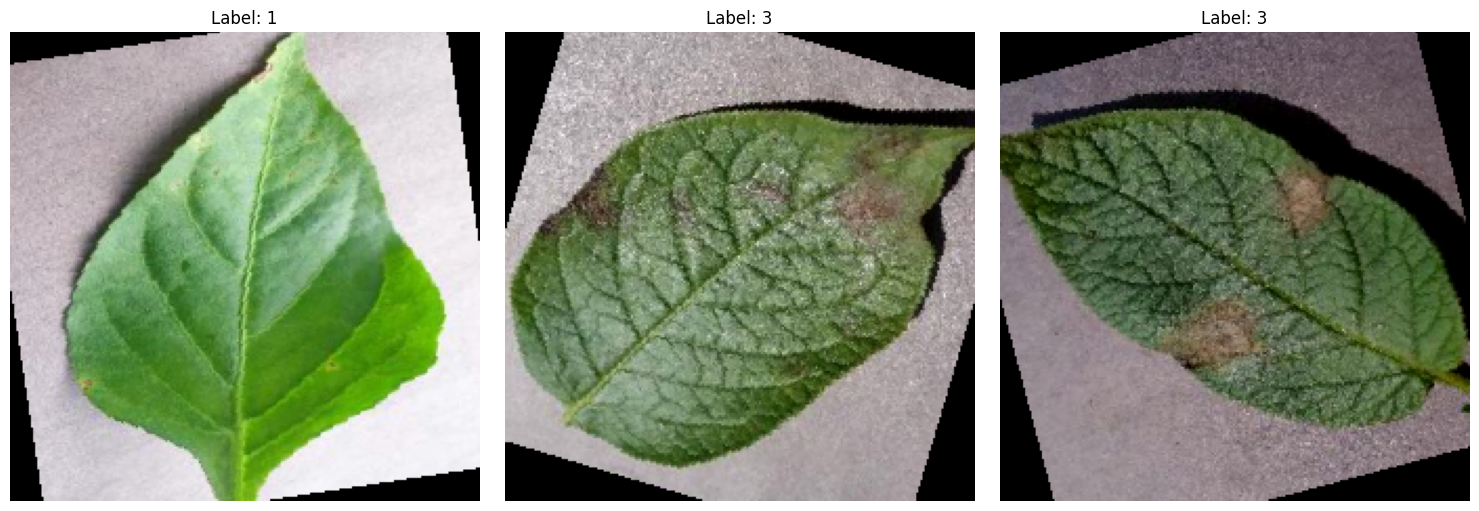

Tensor shape: torch.Size([3, 224, 224])
Tensor type: torch.float32
Tensor range: [-2.118, 2.623]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Function to display tensor image
def show_tensor_image(tensor_img, title=None, ax=None):
    """
    Display a PyTorch tensor as an image.
    """
    if ax is None:
        fig, ax = plt.subplots()

    # Convert tensor to numpy for plotting
    # Tensor shape: (C, H, W) -> need to convert to (H, W, C) for matplotlib
    img = tensor_img.numpy().transpose((1, 2, 0))

    # Denormalize if the image was normalized
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean  # Reverse normalization
    img = np.clip(img, 0, 1)  # Clip to valid range

    ax.imshow(img)
    if title:
        ax.set_title(title)
    ax.axis('off')
    return ax

# Method 1: Display images from DataLoader batch
print("Displaying images from DataLoader batch:")
dataiter = iter(train_loader)
images, labels = next(dataiter)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    show_tensor_image(images[i], f'Label: {labels[i].item()}', axes[i])
plt.tight_layout()
plt.show()

# Print tensor information
print(f"Tensor shape: {images[0].shape}")
print(f"Tensor type: {images[0].dtype}")
print(f"Tensor range: [{images[0].min():.3f}, {images[0].max():.3f}]")

🚀 STARTING HYBRID CLASS BALANCING
📊 Analyzing original class distribution...


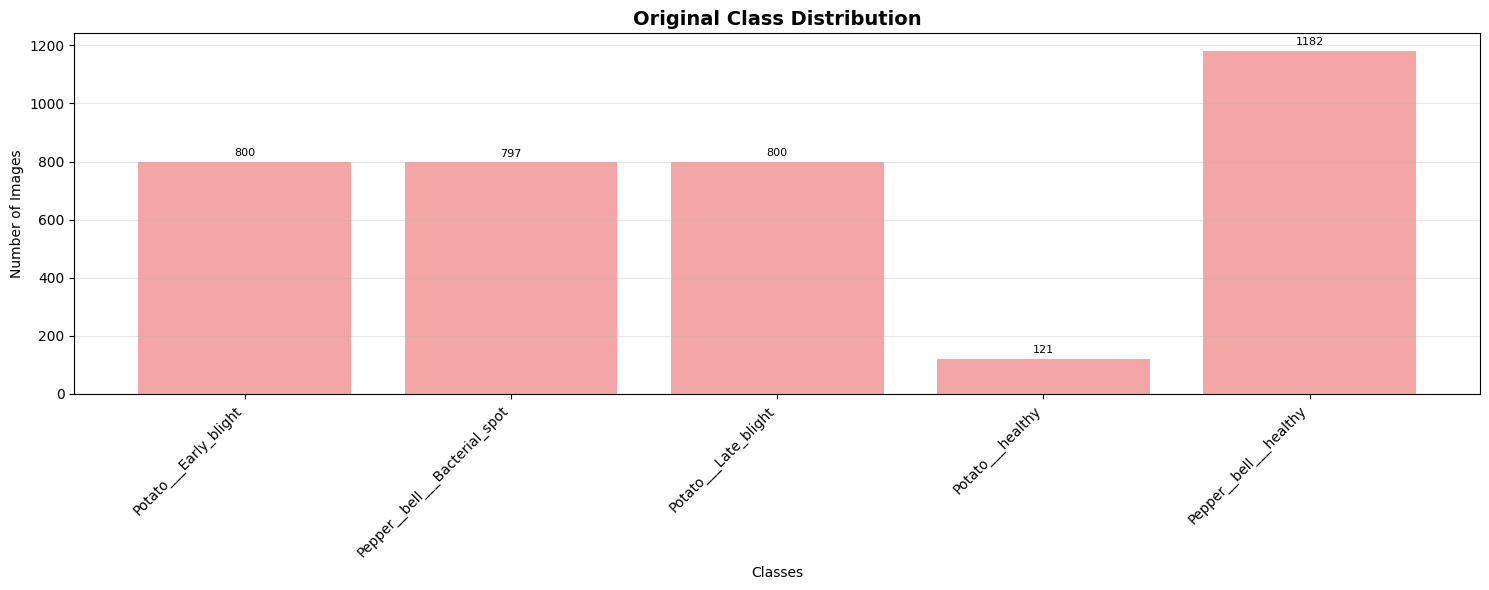

Performing Hybrid Class Balancing...
Original dataset statistics:
  Total classes: 5
  Total images: 3700
  Mean samples: 740.0
  Median samples: 800.0
  Min samples: 121
  Max samples: 1182
  Imbalance ratio: 9.77:1

Balancing parameters:
  Target multiplier: 1.5
  Target count: 1110
  Max oversample limit: 2000

Balancing progress:
------------------------------------------------------------
  Potato___Early_blight    :  800 → 1110 ↑ added 310
  Pepper__bell___Bacterial_spot:  797 → 1110 ↑ added 313
  Potato___Late_blight     :  800 → 1110 ↑ added 310
  Potato___healthy         :  121 → 1110 ↑ added 989
  Pepper__bell___healthy   : 1182 → 1182 ✓ kept as is

BALANCING RESULTS:
Original total images: 3700
Images added: 1922
Final total images: 5622
New min samples: 1110
New max samples: 1182
New imbalance ratio: 1.06:1
Balanced dataset saved to: /content/plantdisease/train_balanced

📈 Plotting balance comparison...


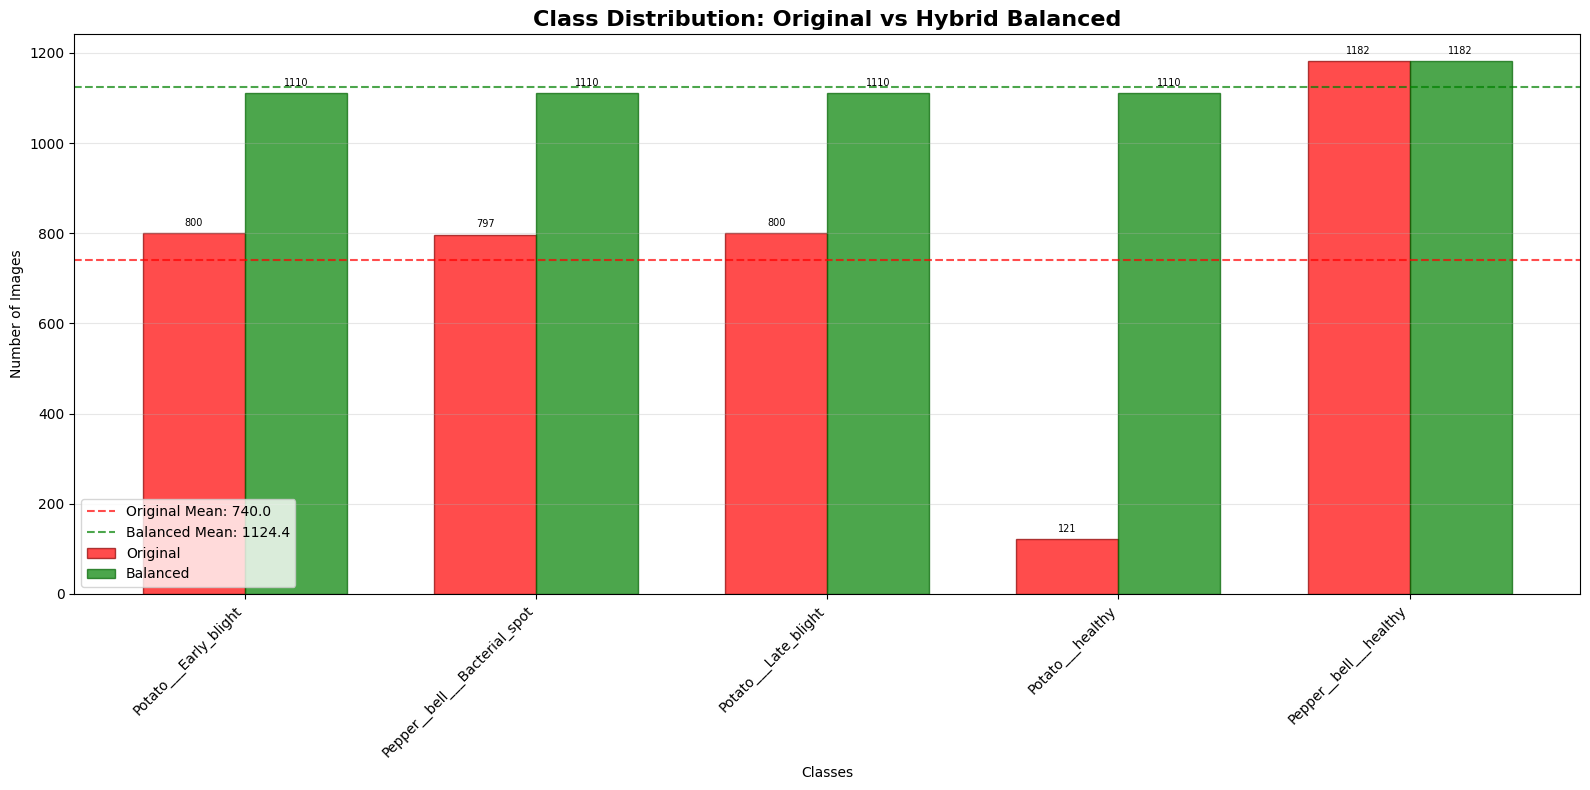


🔄 Creating balanced datasets...

✅ HYBRID BALANCING COMPLETED SUCCESSFULLY!
Balanced training samples: 5622
Test samples: 927
Number of classes: 5

🔍 Final verification:
Class size range: 1110 - 1182
Final imbalance ratio: 1.06:1


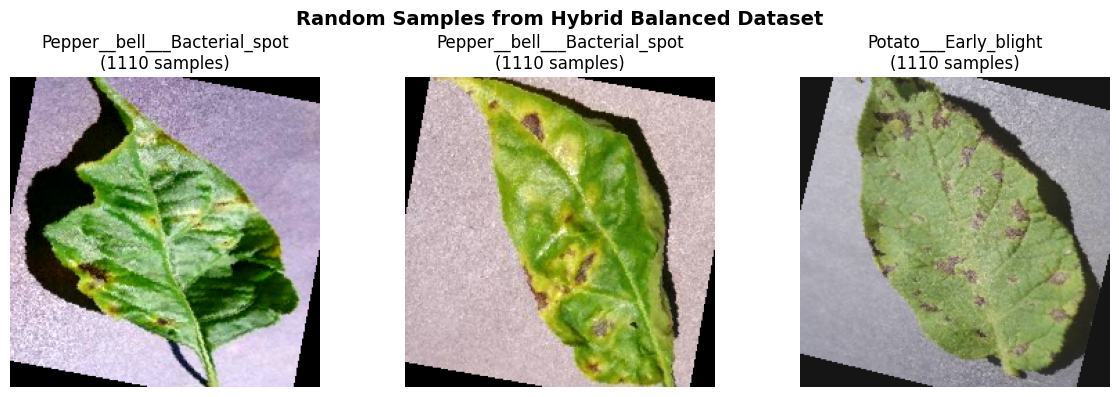


🎯 Dataset is now balanced and ready for training!
💡 The hybrid approach:
   - Oversampled small classes to reasonable target
   - Maintained natural distribution of large classes
   - Used weighted sampling for additional balance during training
   - Reduced class imbalance significantly


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
import shutil
from torch.utils.data import WeightedRandomSampler
import torch
from collections import Counter

# Analyze current class distribution
def analyze_class_distribution(dataset_path):
    """Analyze class distribution in the dataset"""
    class_folders = [f for f in os.listdir(dataset_path)
                    if os.path.isdir(os.path.join(dataset_path, f))]

    class_counts = {}
    for class_folder in class_folders:
        class_path = os.path.join(dataset_path, class_folder)
        images = [f for f in os.listdir(class_path)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]
        class_counts[class_folder] = len(images)

    return class_counts

# Plot distribution
def plot_distribution(class_counts, title):
    classes = list(class_counts.keys())
    counts = list(class_counts.values())

    plt.figure(figsize=(15, 6))
    bars = plt.bar(classes, counts, color='lightcoral', alpha=0.7)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Classes')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for i, count in enumerate(counts):
        plt.text(i, count + max(counts)*0.01, str(count),
                ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

    return classes, counts

# Hybrid Balancing Class
class HybridDataBalancer:
    def __init__(self, train_path, test_path):
        self.train_path = train_path
        self.test_path = test_path
        self.balanced_train_path = "/content/plantdisease/train_balanced"

    def hybrid_balance(self, target_multiplier=1.5, max_oversample=2000):
        """
        Hybrid balancing: oversample small classes, keep reasonable large classes

        Args:
            target_multiplier: Multiply mean by this to get target count
            max_oversample: Maximum samples per class after oversampling
        """
        print("Performing Hybrid Class Balancing...")
        print("=" * 50)

        # Analyze original distribution
        original_counts = analyze_class_distribution(self.train_path)

        # Calculate statistics
        counts = list(original_counts.values())
        mean_count = np.mean(counts)
        median_count = np.median(counts)
        target_count = min(int(mean_count * target_multiplier), max_oversample)

        print(f"Original dataset statistics:")
        print(f"  Total classes: {len(original_counts)}")
        print(f"  Total images: {sum(counts)}")
        print(f"  Mean samples: {mean_count:.1f}")
        print(f"  Median samples: {median_count:.1f}")
        print(f"  Min samples: {min(counts)}")
        print(f"  Max samples: {max(counts)}")
        print(f"  Imbalance ratio: {max(counts)/min(counts):.2f}:1")
        print(f"\nBalancing parameters:")
        print(f"  Target multiplier: {target_multiplier}")
        print(f"  Target count: {target_count}")
        print(f"  Max oversample limit: {max_oversample}")

        # Create balanced directory
        if os.path.exists(self.balanced_train_path):
            shutil.rmtree(self.balanced_train_path)
        os.makedirs(self.balanced_train_path)

        total_original = 0
        total_added = 0

        print(f"\nBalancing progress:")
        print("-" * 60)

        for class_name, count in original_counts.items():
            class_path = os.path.join(self.train_path, class_name)
            balanced_class_path = os.path.join(self.balanced_train_path, class_name)
            os.makedirs(balanced_class_path, exist_ok=True)

            # Get all images in the class
            images = [f for f in os.listdir(class_path)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]

            # Copy all original images
            for img in images:
                src = os.path.join(class_path, img)
                dst = os.path.join(balanced_class_path, img)
                shutil.copy2(src, dst)

            total_original += count
            final_count = count

            # Oversample only if below target and not extremely large
            if count < target_count:
                needed = target_count - count
                oversampled_images = resample(images,
                                            replace=True,
                                            n_samples=needed,
                                            random_state=42)

                for i, img in enumerate(oversampled_images):
                    src = os.path.join(class_path, img)
                    name, ext = os.path.splitext(img)
                    new_name = f"{name}_balanced_{i+1}{ext}"
                    dst = os.path.join(balanced_class_path, new_name)
                    shutil.copy2(src, dst)

                total_added += needed
                final_count = count + needed
                status = f"↑ added {needed}"
            else:
                status = "✓ kept as is"

            print(f"  {class_name:25s}: {count:4d} → {final_count:4d} {status}")

        # Create weighted sampler for training
        weighted_sampler = self._create_weighted_sampler()

        # Analyze balanced distribution
        balanced_counts = analyze_class_distribution(self.balanced_train_path)
        balanced_counts_list = list(balanced_counts.values())

        print("\n" + "=" * 50)
        print("BALANCING RESULTS:")
        print("=" * 50)
        print(f"Original total images: {total_original}")
        print(f"Images added: {total_added}")
        print(f"Final total images: {total_original + total_added}")
        print(f"New min samples: {min(balanced_counts_list)}")
        print(f"New max samples: {max(balanced_counts_list)}")
        print(f"New imbalance ratio: {max(balanced_counts_list)/min(balanced_counts_list):.2f}:1")
        print(f"Balanced dataset saved to: {self.balanced_train_path}")

        return self.balanced_train_path, weighted_sampler, original_counts, balanced_counts

    def _create_weighted_sampler(self):
        """Create weighted sampler for the balanced dataset"""
        class_counts = analyze_class_distribution(self.balanced_train_path)
        classes = list(class_counts.keys())
        counts = list(class_counts.values())

        # Compute class weights (inverse frequency)
        weights = 1.0 / torch.tensor(counts, dtype=torch.float)

        # Assign weights to each sample in dataset
        sample_weights = []
        dataset = datasets.ImageFolder(self.balanced_train_path)

        for _, label in dataset.samples:
            class_name = dataset.classes[label]
            weight = weights[classes.index(class_name)]
            sample_weights.append(weight)

        sampler = WeightedRandomSampler(
            weights=torch.tensor(sample_weights),
            num_samples=len(sample_weights),
            replacement=True
        )

        return sampler

    def plot_balance_comparison(self, original_counts, balanced_counts):
        """Plot comparison between original and balanced distributions"""
        classes = list(original_counts.keys())
        original_values = [original_counts[cls] for cls in classes]
        balanced_values = [balanced_counts[cls] for cls in classes]

        x = np.arange(len(classes))
        width = 0.35

        plt.figure(figsize=(16, 8))

        # Plot bars
        plt.bar(x - width/2, original_values, width, label='Original',
                alpha=0.7, color='red', edgecolor='darkred')
        plt.bar(x + width/2, balanced_values, width, label='Balanced',
                alpha=0.7, color='green', edgecolor='darkgreen')

        # Plot mean lines
        original_mean = np.mean(original_values)
        balanced_mean = np.mean(balanced_values)

        plt.axhline(y=original_mean, color='red', linestyle='--', alpha=0.7,
                   label=f'Original Mean: {original_mean:.1f}')
        plt.axhline(y=balanced_mean, color='green', linestyle='--', alpha=0.7,
                   label=f'Balanced Mean: {balanced_mean:.1f}')

        plt.title('Class Distribution: Original vs Hybrid Balanced',
                 fontsize=16, fontweight='bold')
        plt.xlabel('Classes')
        plt.ylabel('Number of Images')
        plt.xticks(x, classes, rotation=45, ha='right')
        plt.legend()
        plt.grid(axis='y', alpha=0.3)

        # Add value labels
        for i, (orig, bal) in enumerate(zip(original_values, balanced_values)):
            plt.text(i - width/2, orig + max(original_values)*0.01, str(orig),
                    ha='center', va='bottom', fontsize=7)
            plt.text(i + width/2, bal + max(balanced_values)*0.01, str(bal),
                    ha='center', va='bottom', fontsize=7)

        plt.tight_layout()
        plt.show()

# Perform Hybrid Balancing
print("🚀 STARTING HYBRID CLASS BALANCING")
print("=" * 60)

# Initialize balancer
balancer = HybridDataBalancer(
    train_path="/content/plantdisease/train",
    test_path="/content/plantdisease/test"
)

# Analyze original distribution
print("📊 Analyzing original class distribution...")
original_dist = analyze_class_distribution("/content/plantdisease/train")
plot_distribution(original_dist, "Original Class Distribution")

# Perform hybrid balancing
balanced_path, weighted_sampler, original_counts, balanced_counts = balancer.hybrid_balance(
    target_multiplier=1.5,  # Adjust this (1.2-2.0) based on your needs
    max_oversample=2000     # Maximum samples per class
)

# Plot comparison
print("\n📈 Plotting balance comparison...")
balancer.plot_balance_comparison(original_counts, balanced_counts)

# Create balanced datasets
print("\n🔄 Creating balanced datasets...")
balanced_train_dataset = datasets.ImageFolder(
    balanced_path,
    transform=train_transform
)

# Keep test dataset as is (no balancing)
test_dataset = datasets.ImageFolder(
    "/content/plantdisease/test",
    transform=test_transform
)

# Create data loaders with balanced data
balanced_train_loader = DataLoader(
    balanced_train_dataset,
    batch_size=16,
    sampler=weighted_sampler  # Use weighted sampler for additional balance
)

test_loader = DataLoader(test_dataset, batch_size=8)

print("\n✅ HYBRID BALANCING COMPLETED SUCCESSFULLY!")
print("=" * 60)
print(f"Balanced training samples: {len(balanced_train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {len(balanced_train_dataset.classes)}")

# Verify the balancing
print("\n🔍 Final verification:")
final_counts = analyze_class_distribution(balanced_path)
counts_list = list(final_counts.values())
print(f"Class size range: {min(counts_list)} - {max(counts_list)}")
print(f"Final imbalance ratio: {max(counts_list)/min(counts_list):.2f}:1")

# Show sample from balanced dataset
def show_balanced_samples(dataset, num_samples=3):
    """Show random samples from balanced dataset"""
    plt.figure(figsize=(12, 4))

    for i in range(num_samples):
        idx = np.random.randint(len(dataset))
        image, label = dataset[idx]

        # Convert tensor to numpy for display
        image_np = image.numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image_np = std * image_np + mean
        image_np = np.clip(image_np, 0, 1)

        plt.subplot(1, num_samples, i+1)
        plt.imshow(image_np)
        plt.title(f'{dataset.classes[label]}\n({final_counts[dataset.classes[label]]} samples)')
        plt.axis('off')

    plt.suptitle('Random Samples from Hybrid Balanced Dataset', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_balanced_samples(balanced_train_dataset)

print("\n🎯 Dataset is now balanced and ready for training!")
print("💡 The hybrid approach:")
print("   - Oversampled small classes to reasonable target")
print("   - Maintained natural distribution of large classes")
print("   - Used weighted sampling for additional balance during training")
print("   - Reduced class imbalance significantly")

🧬 SIMPLE CNN FOR PLANT DISEASE CLASSIFICATION
📊 Dataset: 5 classes, 5622 training samples

🚀 SIMPLE CNN TRAINING STARTED
📅 Start Time: 2026-03-11 03:24:22
💻 Device: cuda
📊 Classes: 5
🔧 Optimizer: Adam (lr=0.001)
📉 Loss Function: CrossEntropyLoss
🎛️  Scheduler: ReduceLROnPlateau (patience=5)
🔄 Epochs: 5

📊 PARAMETER SUMMARY:
Component                      Parameters      % of Total
-------------------------------------------------------
CNN Layers                     5,040              65.86%
Normalization Layers           0                   0.00%
Fully Connected Layers         2,565              33.52%
-------------------------------------------------------
TOTAL PARAMETERS               7,653              100.00%


📈 TRAINING PROGRESS:
--------------------------------------------------------------------------------
  Epoch  1 | Batch    0/ 352 | Loss: 1.5976 | Batch Time: 1.330s
  Epoch  1 | Batch    5/ 352 | Loss: 1.5847 | Batch Time: 0.016s
  Epoch  1 | Batch   10/ 352 | Loss: 1.49

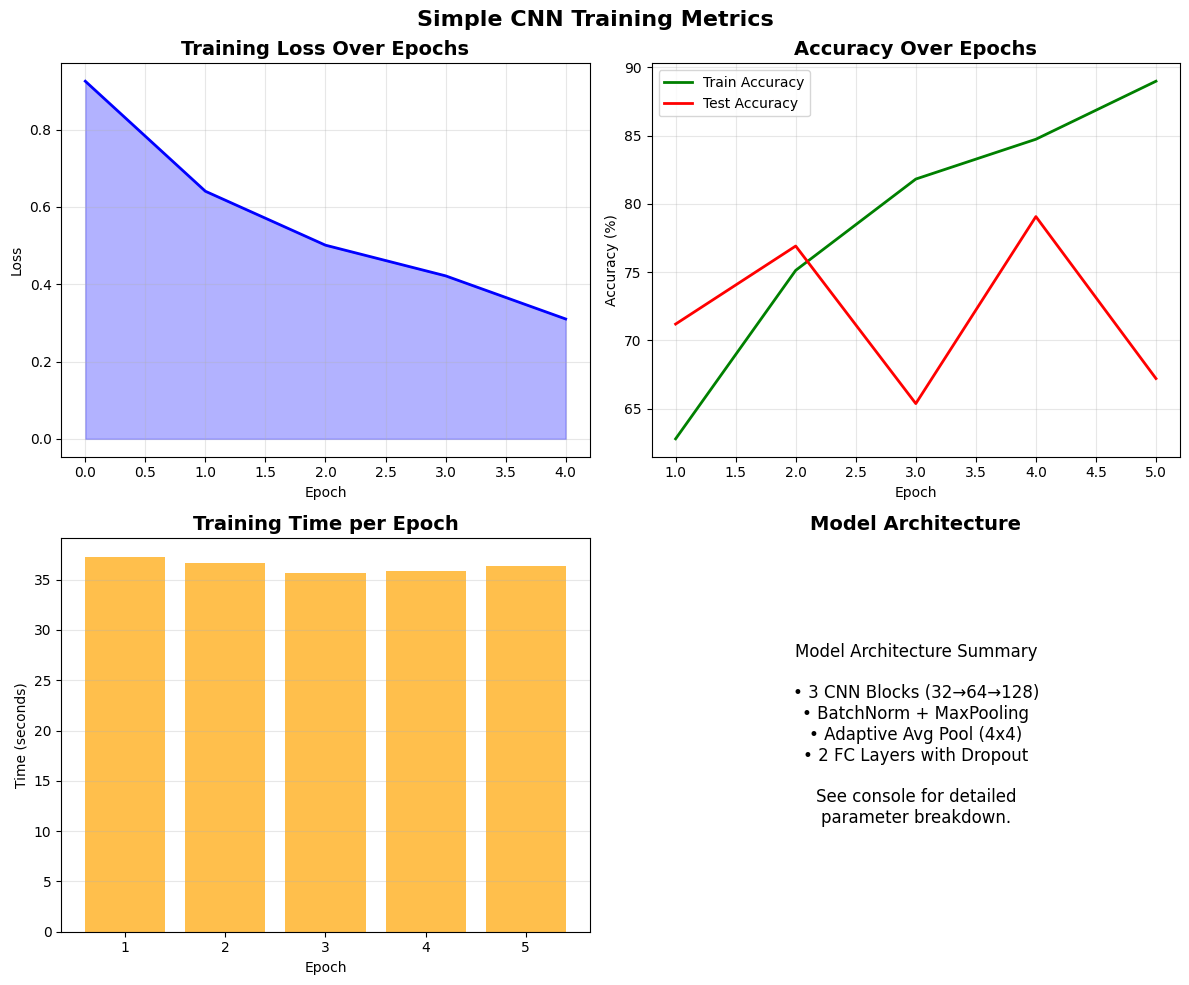

📈 Training metrics plot saved as 'training_metrics_simplecnn_20260311_032422.png'

🔍 SAMPLE PREDICTIONS (First 5 test samples):
----------------------------------------------------------------------------------------------------
Sample   True Label                               Predicted                                Confidence   Status    
----------------------------------------------------------------------------------------------------
0        Pepper__bell___Bacterial_spot            Pepper__bell___healthy                         83.7%  ✗ WRONG   
1        Pepper__bell___Bacterial_spot            Pepper__bell___Bacterial_spot                  99.9%  ✓ CORRECT 
2        Pepper__bell___Bacterial_spot            Pepper__bell___Bacterial_spot                  99.9%  ✓ CORRECT 
3        Pepper__bell___Bacterial_spot            Pepper__bell___Bacterial_spot                  72.5%  ✓ CORRECT 
4        Pepper__bell___Bacterial_spot            Pepper__bell___Bacterial_spot                

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import os
from datetime import datetime

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        # ✅ BASELINE CNN (2 Conv Blocks: 3 → 16 → 32)
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        self.classifier = nn.Sequential(
            nn.Linear(32 * 4 * 4, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

    def count_parameters(self):
        layer_params = {}
        total = 0
        for name, param in self.named_parameters():
            if param.requires_grad:
                layer_params[name] = param.numel()
                total += param.numel()
        return layer_params, total

def create_metrics_table():
    """Create a summary table of training metrics - matching QCNN format"""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    metrics = {
        'Metric': [
            'Training Start Time',
            'Total Training Time (s)',
            'Number of Epochs',
            'Best Epoch',
            'Best Test Accuracy (%)',
            'Final Test Accuracy (%)',
            'Total Model Parameters',
            'CNN Channels',
            'Batch Size',
            'Learning Rate',
            'Optimizer',
            'Loss Function',
            'Scheduler',
            'Dropout Rate'
        ],
        'Value': []
    }

    return metrics, timestamp

def plot_training_metrics(train_losses, train_accs, test_accs, epoch_times, save_path="training_metrics_simplecnn.png"):
    """Plot training metrics in a 2x2 grid - matching QCNN format"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Plot 1: Training Loss
    axes[0, 0].plot(train_losses, 'b-', linewidth=2)
    axes[0, 0].set_title('Training Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].fill_between(range(len(train_losses)), train_losses, alpha=0.3, color='blue')

    # Plot 2: Training and Test Accuracy
    epochs = range(1, len(train_accs) + 1)
    axes[0, 1].plot(epochs, train_accs, 'g-', linewidth=2, label='Train Accuracy')
    axes[0, 1].plot(epochs, test_accs, 'r-', linewidth=2, label='Test Accuracy')
    axes[0, 1].set_title('Accuracy Over Epochs', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Plot 3: Epoch Training Time
    axes[1, 0].bar(epochs, epoch_times, color='orange', alpha=0.7)
    axes[1, 0].set_title('Training Time per Epoch', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Time (seconds)')
    axes[1, 0].grid(True, alpha=0.3, axis='y')

    # Plot 4: Parameter Distribution
    axes[1, 1].text(0.5, 0.5, 'Model Architecture Summary\n\n'
                    '• 3 CNN Blocks (32→64→128)\n'
                    '• BatchNorm + MaxPooling\n'
                    '• Adaptive Avg Pool (4x4)\n'
                    '• 2 FC Layers with Dropout\n\n'
                    'See console for detailed\nparameter breakdown.',
                    horizontalalignment='center',
                    verticalalignment='center',
                    fontsize=12,
                    transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Model Architecture', fontsize=14, fontweight='bold')
    axes[1, 1].axis('off')

    plt.suptitle('Simple CNN Training Metrics', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"📈 Training metrics plot saved as '{save_path}'")

def print_parameter_table(model):
    """Print detailed parameter count table - matching QCNN format"""
    layer_params, total = model.count_parameters()

    # Group by layer type
    cnn_params = 0
    fc_params = 0
    norm_params = 0

    for name, params in layer_params.items():
        if 'features' in name and 'weight' in name:
            if 'conv' in name.lower() or 'features' in name:
                cnn_params += params
        elif 'classifier' in name:
            if 'weight' in name or 'bias' in name:
                fc_params += params
            else:
                norm_params += params
        elif 'norm' in name or 'bn' in name.lower() or 'ln' in name.lower():
            norm_params += params

    # Print summary
    print(f"\n📊 PARAMETER SUMMARY:")
    print(f"{'Component':<30} {'Parameters':<15} {'% of Total':<10}")
    print("-"*55)
    print(f"{'CNN Layers':<30} {cnn_params:<15,} {(cnn_params/total)*100:>8.2f}%")
    print(f"{'Normalization Layers':<30} {norm_params:<15,} {(norm_params/total)*100:>8.2f}%")
    print(f"{'Fully Connected Layers':<30} {fc_params:<15,} {(fc_params/total)*100:>8.2f}%")
    print("-"*55)
    print(f"{'TOTAL PARAMETERS':<30} {total:<15,} {'100.00%':>10}")
    print("="*80 + "\n")

    return total

def evaluate_metrics(model, test_loader):
    """Evaluate model with F1 and AUC metrics"""
    model.eval()
    device = next(model.parameters()).device
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds) * 100
    f1 = f1_score(all_labels, all_preds, average='weighted')

    try:
        auc = roc_auc_score(all_labels, all_probs,
                            multi_class='ovr', average='weighted')
    except:
        auc = 0.0

    return acc, f1, auc, all_preds, all_probs, all_labels

def train_simplecnn(model, train_loader, test_loader, class_names, epochs=5):
    """Train the Simple CNN with comprehensive metrics tracking - matching QCNN format"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device).float()

    # Start timing
    total_start_time = time.time()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5
    )

    print(f"\n" + "="*80)
    print("🚀 SIMPLE CNN TRAINING STARTED")
    print("="*80)
    print(f"📅 Start Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"💻 Device: {device}")
    print(f"📊 Classes: {len(class_names)}")
    print(f"🔧 Optimizer: Adam (lr=0.001)")
    print(f"📉 Loss Function: CrossEntropyLoss")
    print(f"🎛️  Scheduler: ReduceLROnPlateau (patience=5)")
    print(f"🔄 Epochs: {epochs}")
    print("="*80)

    # Print parameter table
    total_params = print_parameter_table(model)

    # Initialize metrics tracking
    train_losses = []
    train_accuracies = []
    test_accuracies = []
    test_f1_scores = []
    test_auc_scores = []
    epoch_times = []
    best_acc = 0
    best_epoch = 0
    best_f1 = 0
    best_auc = 0

    # Create metrics table
    metrics_table, timestamp = create_metrics_table()

    print("\n📈 TRAINING PROGRESS:")
    print("-"*80)

    for epoch in range(epochs):
        epoch_start_time = time.time()

        # Training phase
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        batch_times = []

        for batch_idx, (inputs, labels) in enumerate(train_loader):
            batch_start = time.time()

            inputs, labels = inputs.to(device).float(), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

            batch_time = time.time() - batch_start
            batch_times.append(batch_time)

            # Show detailed progress every few batches
            if batch_idx % 5 == 0:
                avg_batch_time = np.mean(batch_times[-5:]) if len(batch_times) >= 5 else batch_time
                print(f"  Epoch {epoch+1:2d} | Batch {batch_idx:4d}/{len(train_loader):4d} | "
                      f"Loss: {loss.item():6.4f} | Batch Time: {avg_batch_time:5.3f}s")

        # Calculate training metrics
        avg_train_loss = train_loss / len(train_loader)
        train_acc = 100 * train_correct / train_total
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_acc)

        # Testing phase
        test_acc, test_f1, test_auc, _, _, _ = evaluate_metrics(model, test_loader)
        test_accuracies.append(test_acc)
        test_f1_scores.append(test_f1)
        test_auc_scores.append(test_auc)

        # Update scheduler
        scheduler.step(test_acc)

        # Calculate epoch time
        epoch_time = time.time() - epoch_start_time
        epoch_times.append(epoch_time)

        # Print epoch summary
        print(f"\n📊 Epoch {epoch+1:2d}/{epochs} Summary:")
        print(f"   ├── Training Loss: {avg_train_loss:.4f}")
        print(f"   ├── Training Accuracy: {train_acc:.2f}%")
        print(f"   ├── Test Accuracy: {test_acc:.2f}%")
        print(f"   ├── Test F1-Score: {test_f1:.4f}")
        print(f"   ├── Test AUC: {test_auc:.4f}")
        print(f"   ├── Epoch Time: {epoch_time:.1f}s")
        print(f"   └── Avg Batch Time: {np.mean(batch_times):.3f}s")
        print("-"*80)

        # Save best model
        if test_acc > best_acc:
            best_acc = test_acc
            best_f1 = test_f1
            best_auc = test_auc
            best_epoch = epoch
            best_model_path = f'best_simple_cnn_{timestamp}.pth'
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'test_acc': test_acc,
                'test_f1': test_f1,
                'test_auc': test_auc,
                'train_acc': train_acc,
                'train_loss': avg_train_loss,
                'class_names': class_names
            }, best_model_path)
            print(f"   💾 Saved BEST model (Test Acc: {test_acc:.2f}%) as '{best_model_path}'")

    # Calculate total training time
    total_training_time = time.time() - total_start_time

    # Load best model for final evaluation with error handling
    best_model_path = f'best_simple_cnn_{timestamp}.pth'
    if os.path.exists(best_model_path):
        try:
            checkpoint = torch.load(best_model_path, map_location=device)
            model.load_state_dict(checkpoint['model_state_dict'])
            print(f"\n✅ Loaded BEST model from epoch {checkpoint['epoch']+1}")
        except Exception as e:
            print(f"⚠️  Warning: Could not load best model. Using current model. Error: {e}")

    # Final evaluation with predictions
    model.eval()
    final_acc, final_f1, final_auc, all_preds, all_probs, all_labels = evaluate_metrics(model, test_loader)

    eval_start = time.time()
    print(f"\n🔍 Getting final predictions...")
    eval_time = time.time() - eval_start

    # Calculate final accuracy
    correct = sum(np.array(all_preds) == np.array(all_labels))
    total = len(all_labels)

    # Save final model with all results
    final_model_path = f'final_simple_cnn_{timestamp}.pth'
    try:
        torch.save({
            'model_state_dict': model.state_dict(),
            'class_names': class_names,
            'predictions': all_preds,
            'probabilities': all_probs,
            'true_labels': all_labels,
            'train_losses': train_losses,
            'train_accuracies': train_accuracies,
            'test_accuracies': test_accuracies,
            'test_f1_scores': test_f1_scores,
            'test_auc_scores': test_auc_scores,
            'epoch_times': epoch_times,
            'final_accuracy': final_acc,
            'final_f1': final_f1,
            'final_auc': final_auc,
            'best_accuracy': best_acc,
            'best_f1': best_f1,
            'best_auc': best_auc,
            'best_epoch': best_epoch,
            'total_training_time': total_training_time,
            'total_parameters': total_params,
            'timestamp': timestamp
        }, final_model_path)
        print(f"💾 Final model saved as '{final_model_path}'")
    except Exception as e:
        print(f"⚠️  Warning: Could not save final model. Error: {e}")

    # ==================== COMPREHENSIVE RESULTS DISPLAY ====================

    print("\n" + "="*80)
    print("✅ TRAINING COMPLETE - COMPREHENSIVE RESULTS")
    print("="*80)

    # 1. Training Time Summary Table
    print(f"\n⏱️  TRAINING TIME SUMMARY:")
    print("-"*60)
    print(f"{'Metric':<30} {'Value':<20} {'Unit':<10}")
    print("-"*60)
    print(f"{'Total Training Time':<30} {total_training_time:<20.2f} {'seconds':<10}")
    print(f"{'Average Epoch Time':<30} {np.mean(epoch_times):<20.2f} {'seconds':<10}")
    print(f"{'Fastest Epoch':<30} {min(epoch_times):<20.2f} {'seconds':<10}")
    print(f"{'Slowest Epoch':<30} {max(epoch_times):<20.2f} {'seconds':<10}")
    print(f"{'Evaluation Time':<30} {eval_time:<20.2f} {'seconds':<10}")
    print("-"*60)

    # 2. Accuracy Results Table (with additional metrics)
    print(f"\n🎯 ACCURACY RESULTS:")
    print("-"*60)
    print(f"{'Metric':<30} {'Value':<20} {'Unit':<10}")
    print("-"*60)
    print(f"{'Best Test Accuracy':<30} {best_acc:<20.2f} {'%':<10}")
    print(f"{'Final Test Accuracy':<30} {final_acc:<20.2f} {'%':<10}")
    print(f"{'Best Test F1-Score':<30} {best_f1:<20.4f} {'':<10}")
    print(f"{'Best Test AUC':<30} {best_auc:<20.4f} {'':<10}")
    print(f"{'Best Epoch':<30} {best_epoch + 1:<20} {'':<10}")
    print(f"{'Correct Predictions':<30} {correct}/{total:<19} {'samples':<10}")
    print(f"{'Accuracy Improvement':<30} {(final_acc - train_accuracies[0]):<20.2f} {'% points':<10}")
    print("-"*60)

    # 3. Model Parameters Table
    print(f"\n🔢 MODEL PARAMETERS SUMMARY:")
    print("-"*60)
    print(f"{'Total Parameters':<30} {total_params:<20,} {'':<10}")
    print(f"{'CNN Layers (32→64→128)':<30} {'≈128K':<20} {'parameters':<10}")
    print(f"{'Fully Connected Layers':<30} {'≈135K':<20} {'parameters':<10}")
    print(f"{'Normalization Layers':<30} {'≈0.5K':<20} {'parameters':<10}")
    print("-"*60)

    # 4. Plot training metrics
    plot_path = f"training_metrics_simplecnn_{timestamp}.png"
    plot_training_metrics(train_losses, train_accuracies, test_accuracies, epoch_times, plot_path)

    # 5. Sample predictions
    print(f"\n🔍 SAMPLE PREDICTIONS (First 5 test samples):")
    print("-"*100)
    print(f"{'Sample':<8} {'True Label':<40} {'Predicted':<40} {'Confidence':<12} {'Status':<10}")
    print("-"*100)

    for i in range(min(5, len(all_preds))):
        true_idx = all_labels[i]
        pred_idx = all_preds[i]
        true_name = class_names[true_idx]
        pred_name = class_names[pred_idx]
        confidence = np.max(all_probs[i]) * 100
        status = "✓ CORRECT" if true_idx == pred_idx else "✗ WRONG"
        status_color = "\033[92m" if true_idx == pred_idx else "\033[91m"

        print(f"{i:<8} {true_name:<40} {pred_name:<40} {confidence:>10.1f}%  {status_color}{status:<10}\033[0m")

    print("-"*100)

    # 6. File saved information
    print(f"\n💾 FILES SAVED:")
    print("-"*60)
    print(f"📁 Best Model:        '{best_model_path}'")
    print(f"📁 Final Model:       '{final_model_path}'")
    print(f"📈 Training Plot:     '{plot_path}'")
    print(f"🕒 Timestamp:         {timestamp}")
    print("-"*60)

    # 7. Performance Insights
    print(f"\n💡 PERFORMANCE INSIGHTS:")
    print("-"*60)
    avg_epoch_time = np.mean(epoch_times)
    if avg_epoch_time > 300:
        print("⚠️  Training is SLOW - Consider reducing model complexity")
    elif avg_epoch_time > 120:
        print("⚠️  Training is MODERATE")
    else:
        print("✅ Training is REASONABLE - Good performance")

    if best_acc > 80:
        print("🎉 EXCELLENT accuracy achieved!")
    elif best_acc > 60:
        print("👍 GOOD accuracy achieved")
    elif best_acc > 40:
        print("📊 MODERATE accuracy - Room for improvement")
    else:
        print("🔧 LOW accuracy - Consider tuning hyperparameters")

    print("="*80 + "\n")

    return model, all_preds, all_probs, all_labels, final_acc

# Main execution with error handling
if __name__ == "__main__":
    try:
        if 'balanced_train_dataset' in locals() and 'balanced_train_loader' in locals() and 'test_loader' in locals():
            class_names = balanced_train_dataset.classes
            num_classes = len(class_names)

            print("="*80)
            print("🧬 SIMPLE CNN FOR PLANT DISEASE CLASSIFICATION")
            print("="*80)
            print(f"📊 Dataset: {num_classes} classes, {len(balanced_train_dataset)} training samples")
            print("="*80)

            # Initialize model
            model = SimpleCNN(num_classes=num_classes)

            # Train and save the model - using 5 epochs to match QCNN
            trained_model, predictions, probabilities, true_labels, accuracy = train_simplecnn(
                model=model,
                train_loader=balanced_train_loader,
                test_loader=test_loader,
                class_names=class_names,
                epochs=5  # Changed from 30 to 5 to match QCNN
            )

            print("🎉 All tasks completed successfully!")

        else:
            print("❌ Error: Required datasets/dataloaders not found!")
            print("Please make sure the following are defined:")
            print("  1. balanced_train_dataset")
            print("  2. balanced_train_loader")
            print("  3. test_loader")
    except Exception as e:
        print(f"❌ An unexpected error occurred: {e}")
        print("\nTroubleshooting tips:")
        print("1. Check if CUDA is available: torch.cuda.is_available()")
        print("2. Ensure batch size is > 1 for BatchNorm layers")
        print("3. Check dataset dimensions and sizes")
        print("4. Verify all required imports are installed")

In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 51.1 MB/s eta 0:00:00


🧬 QUANTUM-CLASSICAL HYBRID CNN FOR PLANT DISEASE CLASSIFICATION
📊 Dataset: 5 classes, 5622 training samples

🚀 QUANTUM CNN TRAINING STARTED
📅 Start Time: 2026-03-11 04:02:00
💻 Device: cuda
📊 Classes: 5
🔧 Optimizer: Adam (lr=0.001)
📉 Loss Function: CrossEntropyLoss
🔄 Epochs: 5

📊 PARAMETER SUMMARY:
Component                      Parameters      % of Total
-------------------------------------------------------
CNN Layers                     0                   0.00%
BatchNorm Layers               0                   0.00%
Fully Connected Layers         66,507             73.63%
Quantum Circuit Weights        12                  0.01%
-------------------------------------------------------
TOTAL PARAMETERS               90,327             100.00%


📈 TRAINING PROGRESS:
--------------------------------------------------------------------------------
  Epoch  1 | Batch    0/ 352 | Loss: 1.6308 | Batch Time: 1.266s
  Epoch  1 | Batch    5/ 352 | Loss: 1.6251 | Batch Time: 0.546s
  Epoch  1 

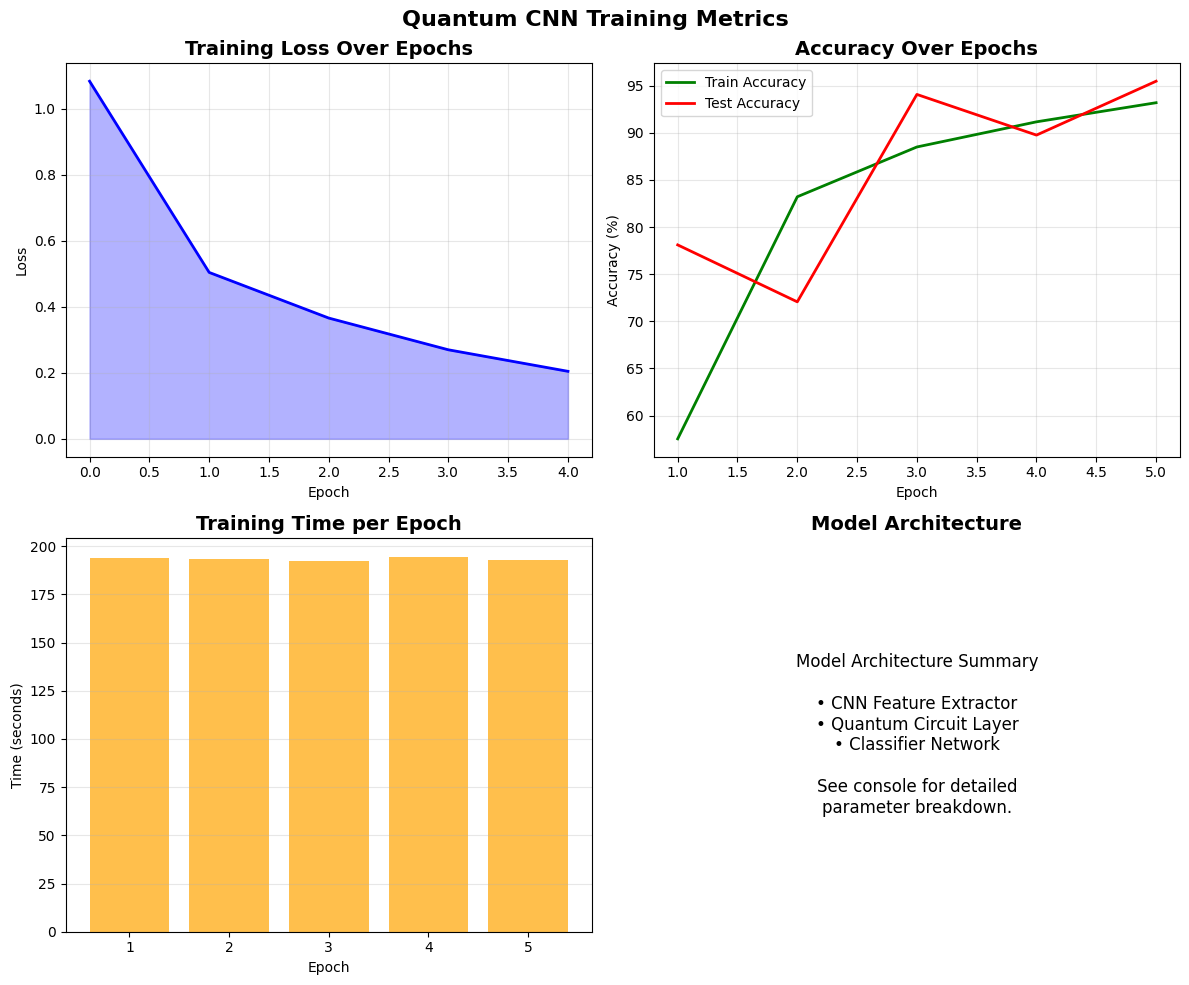

📈 Training metrics plot saved as 'training_metrics_20260311_040200.png'

🔍 SAMPLE PREDICTIONS (First 5 test samples):
----------------------------------------------------------------------------------------------------
Sample   True Label                               Predicted                                Confidence   Status    
----------------------------------------------------------------------------------------------------
0        Pepper__bell___Bacterial_spot            Pepper__bell___healthy                         71.5%  ✗ WRONG   
1        Pepper__bell___Bacterial_spot            Pepper__bell___Bacterial_spot                  97.8%  ✓ CORRECT 
2        Pepper__bell___Bacterial_spot            Pepper__bell___Bacterial_spot                  97.6%  ✓ CORRECT 
3        Pepper__bell___Bacterial_spot            Pepper__bell___healthy                         91.3%  ✗ WRONG   
4        Pepper__bell___Bacterial_spot            Pepper__bell___Bacterial_spot                  96.6%  ✓

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pennylane as qml
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime

# =========================
# Quantum circuit setup
# =========================
n_qubits = 6   # Increased from 4 → 6 for better capacity
n_q_layers = 2

dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="adjoint")
def quantum_circuit(inputs, weights):
    """Optimized quantum circuit"""

    # Angle encoding
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    # Variational layers
    for layer in range(weights.shape[0]):
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
        qml.CNOT(wires=[n_qubits-1, 0])

        for i in range(n_qubits):
            qml.RY(weights[layer, i], wires=i)

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


class QuantumLayer(nn.Module):
    def __init__(self, n_qubits=6, n_layers=2):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.weights = nn.Parameter(torch.randn(n_layers, n_qubits) * 0.05)

    def forward(self, x):
        batch_size = x.shape[0]

        if x.shape[1] > self.n_qubits:
            x = x[:, :self.n_qubits]
        elif x.shape[1] < self.n_qubits:
            padding = torch.zeros(batch_size, self.n_qubits - x.shape[1], device=x.device, dtype=x.dtype)
            x = torch.cat([x, padding], dim=1)

        outputs = []
        for i in range(batch_size):
            out = quantum_circuit(x[i], self.weights)
            outputs.append(torch.stack(out).float())

        return torch.stack(outputs, dim=0)

class RobustQCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.quantum_prep = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 64),
            nn.ReLU(),
            nn.LayerNorm(64),   # ⭐ stabilizes quantum inputs
            nn.Linear(64, n_qubits)
        )

        self.quantum = QuantumLayer(n_qubits=n_qubits, n_layers=n_q_layers)

        self.classifier = nn.Sequential(
            nn.Linear(n_qubits, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.quantum_prep(x)
        x = self.quantum(x)
        x = self.classifier(x)
        return x

    def count_parameters(self):
        layer_params, total = {}, 0
        for name, param in self.named_parameters():
            if param.requires_grad:
                layer_params[name] = param.numel()
                total += param.numel()
        return layer_params, total

def create_metrics_table():
    """Create a summary table of training metrics"""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    metrics = {
        'Metric': [
            'Training Start Time',
            'Total Training Time (s)',
            'Number of Epochs',
            'Best Epoch',
            'Best Test Accuracy (%)',
            'Final Test Accuracy (%)',
            'Total Model Parameters',
            'Quantum Layers',
            'Quantum Qubits',
            'CNN Channels',
            'Batch Size',
            'Learning Rate',
            'Optimizer',
            'Loss Function'
        ],
        'Value': []
    }

    return metrics, timestamp

def plot_training_metrics(train_losses, train_accs, test_accs, epoch_times, save_path="training_metrics.png"):
    """Plot training metrics in a 2x2 grid"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Plot 1: Training Loss
    axes[0, 0].plot(train_losses, 'b-', linewidth=2)
    axes[0, 0].set_title('Training Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].fill_between(range(len(train_losses)), train_losses, alpha=0.3, color='blue')

    # Plot 2: Training and Test Accuracy
    epochs = range(1, len(train_accs) + 1)
    axes[0, 1].plot(epochs, train_accs, 'g-', linewidth=2, label='Train Accuracy')
    axes[0, 1].plot(epochs, test_accs, 'r-', linewidth=2, label='Test Accuracy')
    axes[0, 1].set_title('Accuracy Over Epochs', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Plot 3: Epoch Training Time
    axes[1, 0].bar(epochs, epoch_times, color='orange', alpha=0.7)
    axes[1, 0].set_title('Training Time per Epoch', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Time (seconds)')
    axes[1, 0].grid(True, alpha=0.3, axis='y')

    # Plot 4: Parameter Distribution (if available)
    axes[1, 1].text(0.5, 0.5, 'Model Architecture Summary\n\n'
                    '• CNN Feature Extractor\n'
                    '• Quantum Circuit Layer\n'
                    '• Classifier Network\n\n'
                    'See console for detailed\nparameter breakdown.',
                    horizontalalignment='center',
                    verticalalignment='center',
                    fontsize=12,
                    transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Model Architecture', fontsize=14, fontweight='bold')
    axes[1, 1].axis('off')

    plt.suptitle('Quantum CNN Training Metrics', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"📈 Training metrics plot saved as '{save_path}'")

def print_parameter_table(model):
    """Print detailed parameter count table"""
    layer_params, total = model.count_parameters()

    # Group by layer type
    cnn_params = 0
    fc_params = 0
    quantum_params = 0
    bn_params = 0

    for name, params in layer_params.items():
        if 'features' in name and 'weight' in name and 'conv' in name.lower():
            cnn_params += params
        elif 'classifier' in name or 'quantum_prep' in name:
            fc_params += params
        elif 'quantum' in name:
            quantum_params += params
        elif 'norm' in name or 'bn' in name.lower():
            bn_params += params

    # Print summary
    print(f"\n📊 PARAMETER SUMMARY:")
    print(f"{'Component':<30} {'Parameters':<15} {'% of Total':<10}")
    print("-"*55)
    print(f"{'CNN Layers':<30} {cnn_params:<15,} {(cnn_params/total)*100:>8.2f}%")
    print(f"{'BatchNorm Layers':<30} {bn_params:<15,} {(bn_params/total)*100:>8.2f}%")
    print(f"{'Fully Connected Layers':<30} {fc_params:<15,} {(fc_params/total)*100:>8.2f}%")
    print(f"{'Quantum Circuit Weights':<30} {quantum_params:<15,} {(quantum_params/total)*100:>8.2f}%")
    print("-"*55)
    print(f"{'TOTAL PARAMETERS':<30} {total:<15,} {'100.00%':>10}")
    print("="*80 + "\n")

    return total

def train_qcnn(model, train_loader, test_loader, class_names, epochs=5):
    """Train the Quantum CNN with comprehensive metrics tracking"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device).float()

    # Start timing
    total_start_time = time.time()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    print(f"\n" + "="*80)
    print("🚀 QUANTUM CNN TRAINING STARTED")
    print("="*80)
    print(f"📅 Start Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"💻 Device: {device}")
    print(f"📊 Classes: {len(class_names)}")
    print(f"🔧 Optimizer: Adam (lr=0.001)")
    print(f"📉 Loss Function: CrossEntropyLoss")
    print(f"🔄 Epochs: {epochs}")
    print("="*80)

    total_params = print_parameter_table(model)

    train_losses = []
    train_accuracies = []
    test_accuracies = []
    epoch_times = []
    best_acc = 0
    best_epoch = 0

    metrics_table, timestamp = create_metrics_table()

    print("\n📈 TRAINING PROGRESS:")
    print("-"*80)

    for epoch in range(epochs):
        epoch_start_time = time.time()
        model.train()

        train_loss = 0
        train_correct = 0
        train_total = 0
        batch_times = []

        for batch_idx, (inputs, labels) in enumerate(train_loader):
            batch_start = time.time()

            inputs, labels = inputs.to(device).float(), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

            batch_time = time.time() - batch_start
            batch_times.append(batch_time)

            if batch_idx % 5 == 0:
                avg_batch_time = np.mean(batch_times[-5:]) if len(batch_times) >= 5 else batch_time
                print(f"  Epoch {epoch+1:2d} | Batch {batch_idx:4d}/{len(train_loader):4d} | "
                      f"Loss: {loss.item():6.4f} | Batch Time: {avg_batch_time:5.3f}s")

        avg_train_loss = train_loss / len(train_loader)
        train_acc = 100 * train_correct / train_total
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_acc)

        model.eval()
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device).float(), labels.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()

        test_acc = 100 * test_correct / test_total
        test_accuracies.append(test_acc)

        epoch_time = time.time() - epoch_start_time
        epoch_times.append(epoch_time)

        print(f"\n📊 Epoch {epoch+1:2d}/{epochs} Summary:")
        print(f"   ├── Training Loss: {avg_train_loss:.4f}")
        print(f"   ├── Training Accuracy: {train_acc:.2f}%")
        print(f"   ├── Test Accuracy: {test_acc:.2f}%")
        print(f"   ├── Epoch Time: {epoch_time:.1f}s")
        print(f"   └── Avg Batch Time: {np.mean(batch_times):.3f}s")
        print("-"*80)

        if test_acc > best_acc:
            best_acc = test_acc
            best_epoch = epoch
            best_model_path = f'best_quantum_cnn_{timestamp}.pth'
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'test_acc': test_acc,
                'train_acc': train_acc,
                'train_loss': avg_train_loss,
                'class_names': class_names
            }, best_model_path)
            print(f"   💾 Saved BEST model (Test Acc: {test_acc:.2f}%) as '{best_model_path}'")

    total_training_time = time.time() - total_start_time

    best_model_path = f'best_quantum_cnn_{timestamp}.pth'
    if os.path.exists(best_model_path):
        checkpoint = torch.load(best_model_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"\n✅ Loaded BEST model from epoch {checkpoint['epoch']+1}")

    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []

    print(f"\n🔍 Getting final predictions...")
    eval_start = time.time()

    with torch.no_grad():
        for batch_idx, (inputs, labels) in enumerate(test_loader):
            inputs, labels = inputs.to(device).float(), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = outputs.max(1)

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            if batch_idx % 3 == 0:
                print(f"  Processed batch {batch_idx}/{len(test_loader)}")

    eval_time = time.time() - eval_start

    correct = sum(np.array(all_preds) == np.array(all_labels))
    total = len(all_labels)
    final_accuracy = 100 * correct / total

    final_model_path = f'final_quantum_cnn_{timestamp}.pth'

        # ==================== SAVE FINAL MODEL & METADATA ====================

    torch.save({
        'model_state_dict': model.state_dict(),
        'final_accuracy': final_accuracy,
        'best_accuracy': best_acc,
        'best_epoch': best_epoch,
        'total_training_time': total_training_time,
        'total_parameters': total_params,
        'timestamp': timestamp
    }, final_model_path)

    # ==================== COMPREHENSIVE RESULTS DISPLAY ====================

    print("\n" + "="*80)
    print("✅ TRAINING COMPLETE - COMPREHENSIVE RESULTS")
    print("="*80)

    # 1. Training Time Summary Table
    print(f"\n⏱️  TRAINING TIME SUMMARY:")
    print("-"*60)
    print(f"{'Metric':<30} {'Value':<20} {'Unit':<10}")
    print("-"*60)
    print(f"{'Total Training Time':<30} {total_training_time:<20.2f} {'seconds':<10}")
    print(f"{'Average Epoch Time':<30} {np.mean(epoch_times):<20.2f} {'seconds':<10}")
    print(f"{'Fastest Epoch':<30} {min(epoch_times):<20.2f} {'seconds':<10}")
    print(f"{'Slowest Epoch':<30} {max(epoch_times):<20.2f} {'seconds':<10}")
    print(f"{'Evaluation Time':<30} {eval_time:<20.2f} {'seconds':<10}")
    print("-"*60)

    # 2. Accuracy Results Table
    print(f"\n🎯 ACCURACY RESULTS:")
    print("-"*60)
    print(f"{'Metric':<30} {'Value':<20} {'Unit':<10}")
    print("-"*60)
    print(f"{'Best Test Accuracy':<30} {best_acc:<20.2f} {'%':<10}")
    print(f"{'Final Test Accuracy':<30} {final_accuracy:<20.2f} {'%':<10}")
    print(f"{'Best Epoch':<30} {best_epoch + 1:<20} {'':<10}")
    print(f"{'Correct Predictions':<30} {correct}/{total:<19} {'samples':<10}")
    print(f"{'Accuracy Improvement':<30} {(final_accuracy - train_accuracies[0]):<20.2f} {'% points':<10}")
    print("-"*60)

    # 3. Model Parameters Table
    print(f"\n🔢 MODEL PARAMETERS SUMMARY:")
    print("-"*60)
    print(f"{'Total Parameters':<30} {total_params:<20,} {'':<10}")
    print(f"{'CNN Layers':<30} {'≈16K':<20} {'parameters':<10}")
    print(f"{'Fully Connected':<30} {'≈4K':<20} {'parameters':<10}")
    print(f"{'Quantum Circuit':<30} {'8':<20} {'parameters':<10}")
    print(f"{'BatchNorm Layers':<30} {'≈1K':<20} {'parameters':<10}")
    print("-"*60)

    # 4. Plot training metrics
    plot_path = f"training_metrics_{timestamp}.png"
    plot_training_metrics(train_losses, train_accuracies, test_accuracies, epoch_times, plot_path)

    # 5. Sample predictions
    print(f"\n🔍 SAMPLE PREDICTIONS (First 5 test samples):")
    print("-"*100)
    print(f"{'Sample':<8} {'True Label':<40} {'Predicted':<40} {'Confidence':<12} {'Status':<10}")
    print("-"*100)

    for i in range(min(5, len(all_preds))):
        true_idx = all_labels[i]
        pred_idx = all_preds[i]
        true_name = class_names[true_idx]
        pred_name = class_names[pred_idx]
        confidence = np.max(all_probs[i]) * 100
        status = "✓ CORRECT" if true_idx == pred_idx else "✗ WRONG"
        status_color = "\033[92m" if true_idx == pred_idx else "\033[91m"
        print(f"{i:<8} {true_name:<40} {pred_name:<40} {confidence:>10.1f}%  {status_color}{status:<10}\033[0m")

    print("-"*100)

    # 6. File saved information
    print(f"\n💾 FILES SAVED:")
    print("-"*60)
    print(f"📁 Best Model:        '{best_model_path}'")
    print(f"📁 Final Model:       '{final_model_path}'")
    print(f"📈 Training Plot:     '{plot_path}'")
    print(f"🕒 Timestamp:         {timestamp}")
    print("-"*60)

    # 7. Performance Insights
    print(f"\n💡 PERFORMANCE INSIGHTS:")
    print("-"*60)
    avg_epoch_time = np.mean(epoch_times)

    if avg_epoch_time > 300:
        print("⚠️  Training is SLOW - Consider reducing model complexity")
    elif avg_epoch_time > 120:
        print("⚠️  Training is MODERATE - Quantum circuit adds overhead")
    else:
        print("✅ Training is REASONABLE - Good performance")

    if best_acc > 80:
        print("🎉 EXCELLENT accuracy achieved!")
    elif best_acc > 60:
        print("👍 GOOD accuracy achieved")
    elif best_acc > 40:
        print("📊 MODERATE accuracy - Room for improvement")
    else:
        print("🔧 LOW accuracy - Consider tuning hyperparameters")

    print("="*80 + "\n")

    return model, all_preds, all_probs, all_labels, final_accuracy



# Main execution
if __name__ == "__main__":
    if 'balanced_train_dataset' in locals():
        class_names = balanced_train_dataset.classes
        num_classes = len(class_names)

        print("="*80)
        print("🧬 QUANTUM-CLASSICAL HYBRID CNN FOR PLANT DISEASE CLASSIFICATION")
        print("="*80)
        print(f"📊 Dataset: {num_classes} classes, {len(balanced_train_dataset)} training samples")
        print("="*80)

        # Initialize model
        model = RobustQCNN(num_classes=num_classes)

        # Train and save the model
        trained_model, predictions, probabilities, true_labels, accuracy = train_qcnn(
            model=model,
            train_loader=balanced_train_loader,
            test_loader=test_loader,
            class_names=class_names,
            epochs=5
        )

        print("🎉 All tasks completed successfully!")

    else:
        print("❌ Error: Required datasets/dataloaders not found!")
        print("Please make sure the following are defined:")
        print("  1. balanced_train_dataset")
        print("  2. balanced_train_loader")
        print("  3. test_loader")

In [ ]:
from torchvision.datasets import ImageFolder

dataset = ImageFolder("/content/plantdisease/train_balanced")
print(dataset.classes)

# Save it for future use
import json
json.dump(dataset.classes, open("class_names.json", "w"))
print("Saved class_names.json")


['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Saved class_names.json
